# Linear Transformations

This notebook demonstrates how a transformation matrix changes 2D points and vectors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def plotlines(*line_inputs, title='Line Plot', xlabel='x', ylabel='y', figsize=(7, 7),
              axis_lines=True, equal_aspect=True, grid_alpha=0.3, linewidth=2):
    """Plot multiple lines on a shared 2D axis.

    Each entry in line_inputs can be:
    - (x, y, label)
    - (x, y, label, fmt)
    - (x, y, label, fmt, style_dict)
    """
    plt.figure(figsize=figsize)

    for entry in line_inputs:
        if len(entry) == 3:
            x, y, label = entry
            fmt = None
            style = {}
        elif len(entry) == 4:
            x, y, label, fmt = entry
            style = {}
        elif len(entry) == 5:
            x, y, label, fmt, style = entry
        else:
            raise ValueError('Each line entry must be (x, y, label), (x, y, label, fmt), or (x, y, label, fmt, style_dict).')

        if fmt is None:
            plt.plot(x, y, linewidth=linewidth, label=label, **style)
        else:
            plt.plot(x, y, fmt, linewidth=linewidth, label=label, **style)

    if axis_lines:
        plt.axhline(0, color='gray', linewidth=1)
        plt.axvline(0, color='gray', linewidth=1)

    if equal_aspect:
        plt.gca().set_aspect('equal', adjustable='box')

    plt.grid(alpha=grid_alpha)
    plt.legend()
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

## Original Shape
We start with a unit square represented by 4 corner points.

In [2]:
square = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
    [0, 0]
], dtype=float)

print('Original points:')
print(square)

Original points:
[[0. 0.]
 [1. 0.]
 [1. 1.]
 [0. 1.]
 [0. 0.]]


## Transformation Matrix
Use a matrix for scaling + rotation-like effect: 
$$
A = \begin{bmatrix} 2 & -0.5 \\ 0.5 & 1.5 \end{bmatrix}
$$

In [3]:
A = np.array([
    [2.0, -0.5],
    [0.5, 1.5]
])

# np.matmul(A, B) is equivalent to A @ B
transformed = np.matmul(A, square.T).T

print('Transformation matrix A:')
print(A)
print()
print('Transformed points:')
print(transformed)

Transformation matrix A:
[[ 2.  -0.5]
 [ 0.5  1.5]]

Transformed points:
[[ 0.   0. ]
 [ 2.   0.5]
 [ 1.5  2. ]
 [-0.5  1.5]
 [ 0.   0. ]]


## Plot Original vs Transformed

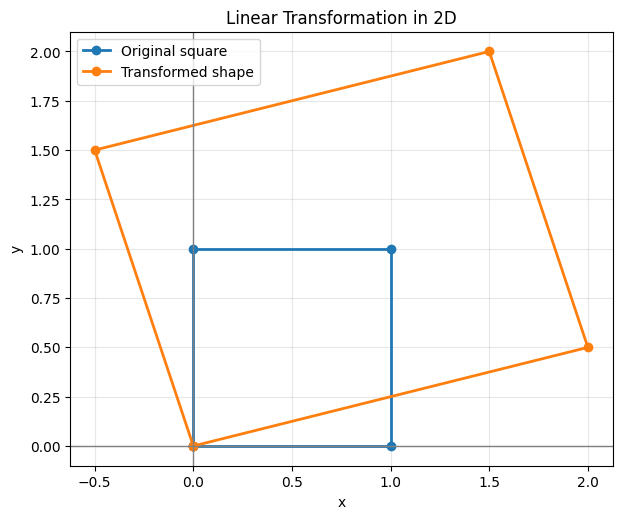

In [4]:
plotlines(
    (square[:, 0], square[:, 1], 'Original square', 'o-'),
    (transformed[:, 0], transformed[:, 1], 'Transformed shape', 'o-'),
    title='Linear Transformation in 2D'
)

## Rotation by Angle (Simple Line Equation)

Take a simple line equation

$$
y = 0.5x + 1
$$

Generate points on this line, rotate them by a chosen angle $\theta$, and plot original vs rotated line.

Rotation matrix R:
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]


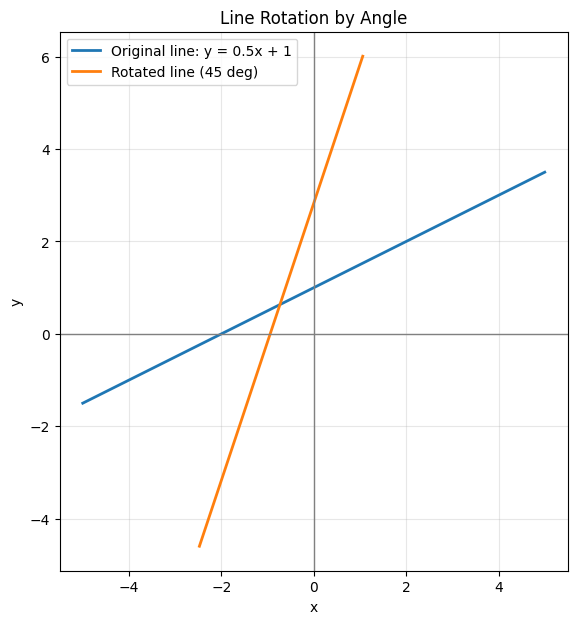

In [5]:
# Simple line equation y = 0.5x + 1
x_line = np.linspace(-5, 5, 100)
y_line = 0.5 * x_line + 1

line_points = np.vstack((x_line, y_line))

# Rotation angle (degrees)
angle_deg = 45
theta = np.deg2rad(angle_deg)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)]
])

print('Rotation matrix R:')
print(R)

# Explicit NumPy method for matrix multiplication
rotated_line = np.matmul(R, line_points)
x_rot, y_rot = rotated_line[0], rotated_line[1]

plotlines(
    (x_line, y_line, 'Original line: y = 0.5x + 1'),
    (x_rot, y_rot, f'Rotated line ({angle_deg} deg)'),
    title='Line Rotation by Angle'
)

## Scale Up and Scale Down (Simple Line Equation)

Use the same line equation $y = 0.5x + 1$ and apply scaling transformations:

- scale up by factor 1.8
- scale down by factor 0.6

> **Note:** You see 3 lines because we plot 3 datasets on the same graph: (1) the original line, (2) the scaled-up line, and (3) the scaled-down line. Scaling changes the distance of each point from the origin, so the transformed lines appear as separate lines.

Scale-up matrix S_up:
[[1.8 0. ]
 [0.  1.8]]

Scale-down matrix S_down:
[[0.6 0. ]
 [0.  0.6]]


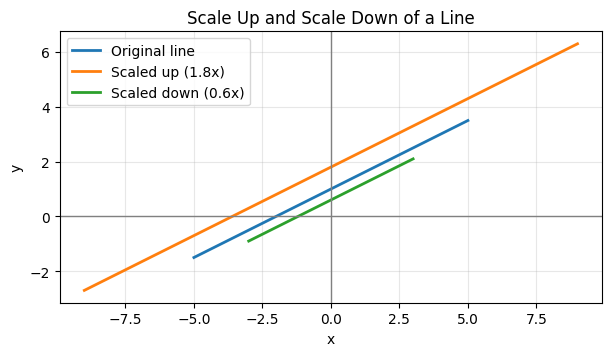

In [6]:
# Reuse simple line equation points
x_scale = np.linspace(-5, 5, 100)
y_scale = 0.5 * x_scale + 1
line_scale = np.vstack((x_scale, y_scale))

# Scaling factors
scale_up = 1.8
scale_down = 0.6

S_up = np.array([[scale_up, 0], [0, scale_up]])
S_down = np.array([[scale_down, 0], [0, scale_down]])

print('Scale-up matrix S_up:')
print(S_up)
print()
print('Scale-down matrix S_down:')
print(S_down)

line_up = np.matmul(S_up, line_scale)
line_down = np.matmul(S_down, line_scale)

plotlines(
    (line_scale[0], line_scale[1], 'Original line'),
    (line_up[0], line_up[1], f'Scaled up ({scale_up}x)'),
    (line_down[0], line_down[1], f'Scaled down ({scale_down}x)'),
    title='Scale Up and Scale Down of a Line'
)

## Reflection

Apply reflection matrices to the same line $y = 0.5x + 1$.

> **Note:** Reflection is a mirror flip of points across an axis (or line). It keeps distances and shape the same, but reverses orientation. Across the x-axis, $(x, y) \rightarrow (x, -y)$. Across the y-axis, $(x, y) \rightarrow (-x, y)$.

- Across x-axis: $R_x = \begin{bmatrix}1 & 0 \\ 0 & -1\end{bmatrix}$
- Across y-axis: $R_y = \begin{bmatrix}-1 & 0 \\ 0 & 1\end{bmatrix}$

Reflection matrix across x-axis:
[[ 1  0]
 [ 0 -1]]

Reflection matrix across y-axis:
[[-1  0]
 [ 0  1]]


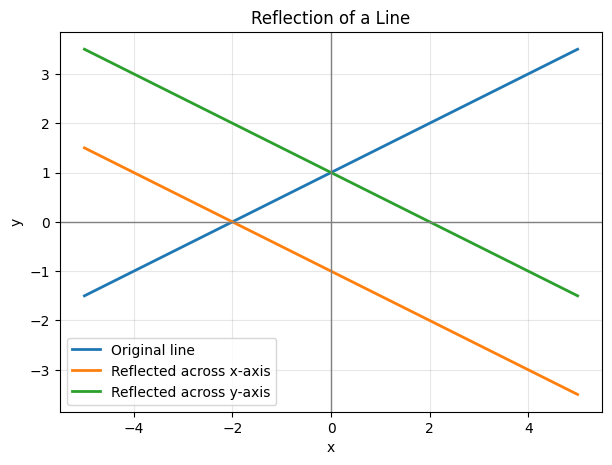

In [7]:
x_ref = np.linspace(-5, 5, 100)
y_ref = 0.5 * x_ref + 1
line_ref = np.vstack((x_ref, y_ref))

R_x = np.array([[1, 0], [0, -1]])
R_y = np.array([[-1, 0], [0, 1]])

line_ref_x = np.matmul(R_x, line_ref)
line_ref_y = np.matmul(R_y, line_ref)

print('Reflection matrix across x-axis:')
print(R_x)
print()
print('Reflection matrix across y-axis:')
print(R_y)

plotlines(
    (line_ref[0], line_ref[1], 'Original line'),
    (line_ref_x[0], line_ref_x[1], 'Reflected across x-axis'),
    (line_ref_y[0], line_ref_y[1], 'Reflected across y-axis'),
    title='Reflection of a Line'
)

## Shear

Apply shear transformations to the same line.

> **Note:** Shear is a slanting transformation. It pushes points in one direction based on their coordinate in the other direction, so parallel lines stay parallel but angles are generally not preserved.

- Horizontal shear: $H = \begin{bmatrix}1 & k \\ 0 & 1\end{bmatrix}$
- Vertical shear: $V = \begin{bmatrix}1 & 0 \\ k & 1\end{bmatrix}$

**Key takeaway:** Shear changes shape (angles), but not the overall “parallel-ness” of lines.

Horizontal shear matrix H:
[[1.  0.8]
 [0.  1. ]]

Vertical shear matrix V:
[[1.  0. ]
 [0.8 1. ]]


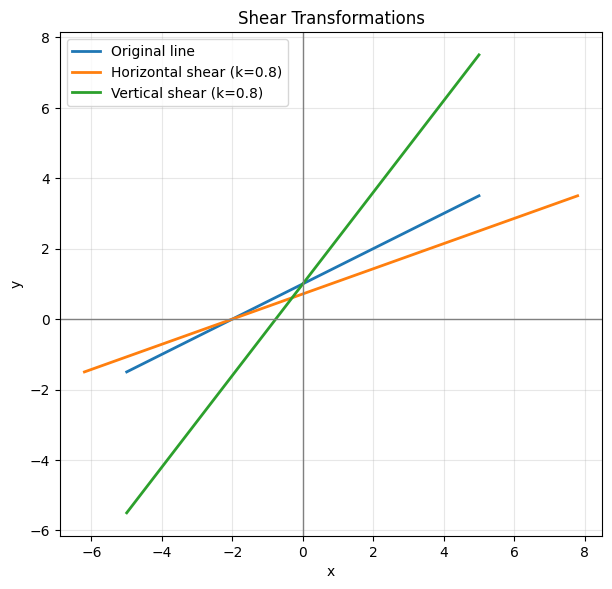

In [8]:
x_sh = np.linspace(-5, 5, 100)
y_sh = 0.5 * x_sh + 1
line_sh = np.vstack((x_sh, y_sh))

k = 0.8
H = np.array([[1, k], [0, 1]])
V = np.array([[1, 0], [k, 1]])

line_h = np.matmul(H, line_sh)
line_v = np.matmul(V, line_sh)

print('Horizontal shear matrix H:')
print(H)
print()
print('Vertical shear matrix V:')
print(V)

plotlines(
    (line_sh[0], line_sh[1], 'Original line'),
    (line_h[0], line_h[1], f'Horizontal shear (k={k})'),
    (line_v[0], line_v[1], f'Vertical shear (k={k})'),
    title='Shear Transformations'
)

## Composition Order: AB vs BA

This example shows that order matters in matrix multiplication:

$$
(AB)\mathbf{v} \neq (BA)\mathbf{v}
$$

> **Note:** Composition means applying one transformation after another. Matrix multiplication is not commutative, so changing the order usually changes the final result. That is why rotate-then-scale and scale-then-rotate produce different lines.

We compare rotate-then-scale versus scale-then-rotate on the same line.

**Key takeaway:** In transformations, the order of operations is part of the answer, not just the matrices themselves.

R30 @ S:
[[ 1.73205081 -0.35      ]
 [ 1.          0.60621778]]

S @ R30:
[[ 1.73205081 -1.        ]
 [ 0.35        0.60621778]]


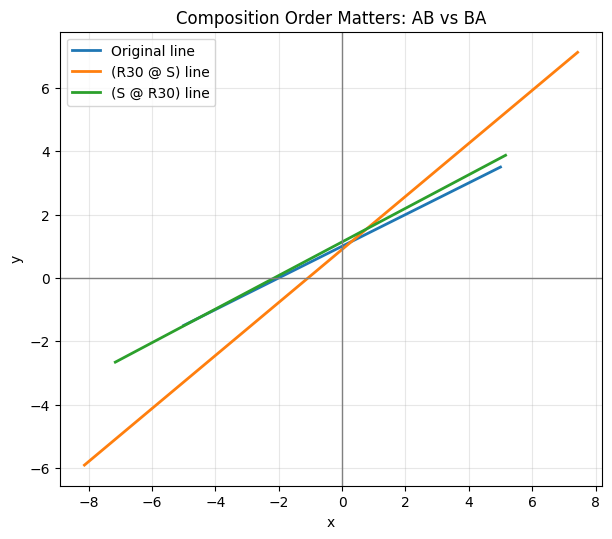

In [9]:
x_comp = np.linspace(-5, 5, 100)
y_comp = 0.5 * x_comp + 1
line_comp = np.vstack((x_comp, y_comp))

theta_comp = np.deg2rad(30)
R30 = np.array([
    [np.cos(theta_comp), -np.sin(theta_comp)],
    [np.sin(theta_comp),  np.cos(theta_comp)]
])

S = np.array([
    [2.0, 0.0],
    [0.0, 0.7]
])

line_RS = np.matmul(np.matmul(R30, S), line_comp)
line_SR = np.matmul(np.matmul(S, R30), line_comp)

print('R30 @ S:')
print(np.matmul(R30, S))
print()
print('S @ R30:')
print(np.matmul(S, R30))

plotlines(
    (line_comp[0], line_comp[1], 'Original line'),
    (line_RS[0], line_RS[1], '(R30 @ S) line'),
    (line_SR[0], line_SR[1], '(S @ R30) line'),
    title='Composition Order Matters: AB vs BA'
)

## Other Linear Transformations (Reference)

Here are some additional common 2D linear transformations and their matrices:

- **Identity (no change):**
  $$
  I = \begin{bmatrix}1 & 0 \\ 0 & 1\end{bmatrix}
  $$

- **Non-uniform scaling (different scale on each axis):**
  $$
  S = \begin{bmatrix}s_x & 0 \\ 0 & s_y\end{bmatrix}
  $$

- **Projection onto x-axis:**
  $$
  P_x = \begin{bmatrix}1 & 0 \\ 0 & 0\end{bmatrix}
  $$

- **Projection onto y-axis:**
  $$
  P_y = \begin{bmatrix}0 & 0 \\ 0 & 1\end{bmatrix}
  $$

- **Projection onto line $y=x$:**
  $$
  P_{y=x} = \frac{1}{2}\begin{bmatrix}1 & 1 \\ 1 & 1\end{bmatrix}
  $$

- **Reflection through origin (180° rotation):**
  $$
  R_o = \begin{bmatrix}-1 & 0 \\ 0 & -1\end{bmatrix}
  $$